<a href="https://colab.research.google.com/github/joyjit-das/sof-tiu-ai-lab-1/blob/main/ai_lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem 1: BFS and DFS Traversal of a Graph:
Problem Statement:
A small graph, shaped like a tree with six nodes (A, B, C, D, E, F) and node A as the root, is given below. Write a Python program that:
1. Stores the graph using an adjacency list (a Python dictionary).
2. Performs a BFS traversal starting from node A.
3. Performs a DFS traversal starting from node A.
4. Prints both traversal orders, and draws two separate tree diagrams — one showing the order in which BFS visits the nodes, and another showing the order in which DFS visits the nodes.

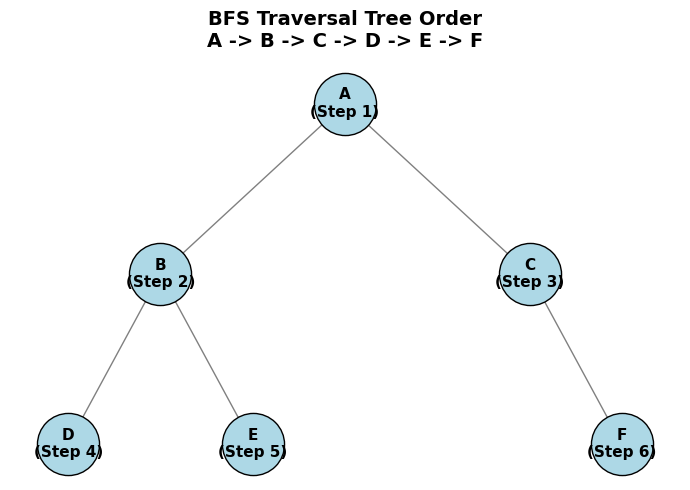

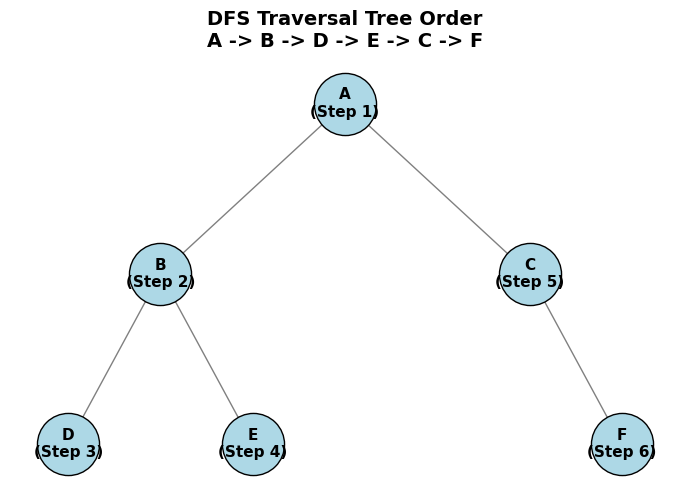

In [3]:
import matplotlib.pyplot as plt
import networkx as nx

# 1. Graph representation using an adjacency list (dictionary)
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}

# 2. BFS Traversal using standard list as Queue
def bfs(graph, start_node):
    visited = []
    queue = [start_node]
    while len(queue) > 0:
        node = queue.pop(0)
        if node not in visited:
            visited.append(node)
            for neighbor in graph[node]:
                if neighbor not in visited and neighbor not in queue:
                    queue.append(neighbor)
    return visited

# 3. DFS Traversal using standard list as Stack
def dfs(graph, start_node):
    visited = []
    stack = [start_node]
    while len(stack) > 0:
        node = stack.pop()
        if node not in visited:
            visited.append(node)
            for neighbor in reversed(graph[node]):
                if neighbor not in visited:
                    stack.append(neighbor)
    return visited

# Compute traversal orders
bfs_order = bfs(graph, 'A')
dfs_order = dfs(graph, 'A')

# Helper function to plot tree diagrams using Matplotlib
def draw_traversal_tree(graph_dict, traversal_order, title):
    # Create NetworkX graph
    G = nx.DiGraph(graph_dict)

    # Manual tree node positions (X, Y layout)
    pos = {
        'A': (0, 2),
        'B': (-1, 1),
        'C': (1, 1),
        'D': (-1.5, 0),
        'E': (-0.5, 0),
        'F': (1.5, 0)
    }

    plt.figure(figsize=(7, 5))

    # Draw graph edges and node circles
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20, edge_color='gray')
    nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightblue', edgecolors='black')

    # Format labels with visit order: e.g., "A\n(1)"
    labels = {}
    for node in G.nodes():
        step_num = traversal_order.index(node) + 1
        labels[node] = f"{node}\n(Step {step_num})"

    nx.draw_networkx_labels(G, pos, labels=labels, font_size=11, font_weight='bold')

    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# 4. Draw trees showing BFS and DFS order
draw_traversal_tree(graph, bfs_order, f"BFS Traversal Tree Order\n{' -> '.join(bfs_order)}")
draw_traversal_tree(graph, dfs_order, f"DFS Traversal Tree Order\n{' -> '.join(dfs_order)}")